RMSProp (Root Mean Square Propagation) adapts the learning rate for each parameter individually, using a moving average of the squared gradients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Parameters
theta0 = 0
theta1 = 0
alpha = 0.01
beta = 0.9
epsilon = 1e-8
iterations = 100

# Initialize accumulators
E_g2_theta0 = 0
E_g2_theta1 = 0

m = len(X)

# RMSProp loop
for i in range(iterations):
    prediction = theta0 + theta1 * X
    error = prediction - y

    # Gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Accumulate squared gradients
    E_g2_theta0 = beta * E_g2_theta0 + (1 - beta) * d_theta0**2
    E_g2_theta1 = beta * E_g2_theta1 + (1 - beta) * d_theta1**2

    # Parameter updates
    theta0 -= (alpha / (np.sqrt(E_g2_theta0) + epsilon)) * d_theta0
    theta1 -= (alpha / (np.sqrt(E_g2_theta1) + epsilon)) * d_theta1

    # Optional: print loss
    if i % 10 == 0:
        loss = np.mean((theta0 + theta1 * X - y) ** 2)
        print(f"Iteration {i}: Loss = {loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 0: Loss = 42.2471
Iteration 10: Loss = 34.4269
Iteration 20: Loss = 29.4040
Iteration 30: Loss = 25.1352
Iteration 40: Loss = 21.3226
Iteration 50: Loss = 17.8811
Iteration 60: Loss = 14.7812
Iteration 70: Loss = 12.0107
Iteration 80: Loss = 9.5628
Iteration 90: Loss = 7.4316

Final theta0: 1.0058157450143714, theta1: 1.0124782595536137


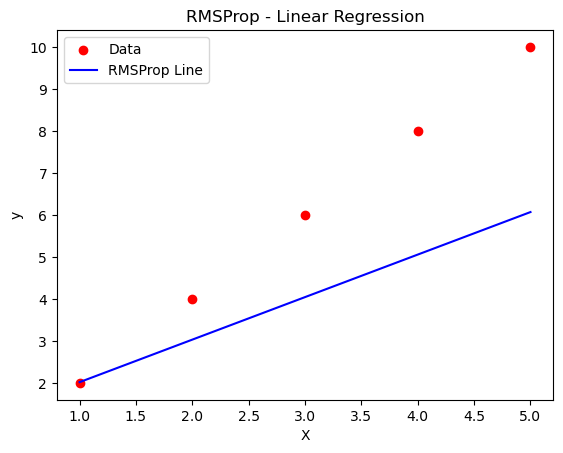

In [2]:
# Plotting
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='RMSProp Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("RMSProp - Linear Regression")
plt.show()

# Adam Optimization
Adam combines momentum and RMSProp, adapting step sizes and 
smoothing updates. It is one of the most popular optimization algorithms in ML

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Parameters
theta0 = 0
theta1 = 0
alpha = 0.01
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
iterations = 100

# Initialize moments
m0 = 0
m1 = 0
v0 = 0
v1 = 0

m = len(X)

# Adam optimizer loop
for t in range(1, iterations + 1):
    prediction = theta0 + theta1 * X
    error = prediction - y

    # Gradients
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X)

    # Update biased first moment
    m0 = beta1 * m0 + (1 - beta1) * d_theta0
    m1 = beta1 * m1 + (1 - beta1) * d_theta1

    # Update biased second moment
    v0 = beta2 * v0 + (1 - beta2) * (d_theta0 ** 2)
    v1 = beta2 * v1 + (1 - beta2) * (d_theta1 ** 2)

    # Bias correction
    m0_hat = m0 / (1 - beta1 ** t)
    m1_hat = m1 / (1 - beta1 ** t)
    v0_hat = v0 / (1 - beta2 ** t)
    v1_hat = v1 / (1 - beta2 ** t)

    # Update parameters
    theta0 -= alpha * m0_hat / (np.sqrt(v0_hat) + epsilon)
    theta1 -= alpha * m1_hat / (np.sqrt(v1_hat) + epsilon)

    # Optional: print loss
    if t % 10 == 0:
        loss = np.mean((theta0 + theta1 * X - y) ** 2)
        print(f"Iteration {t}: Loss = {loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 10: Loss = 38.5914
Iteration 20: Loss = 33.6002
Iteration 30: Loss = 29.0592
Iteration 40: Loss = 24.9772
Iteration 50: Loss = 21.3434
Iteration 60: Loss = 18.1352
Iteration 70: Loss = 15.3236
Iteration 80: Loss = 12.8768
Iteration 90: Loss = 10.7624
Iteration 100: Loss = 8.9482

Final theta0: 0.8616016955905905, theta1: 0.8699186386052477


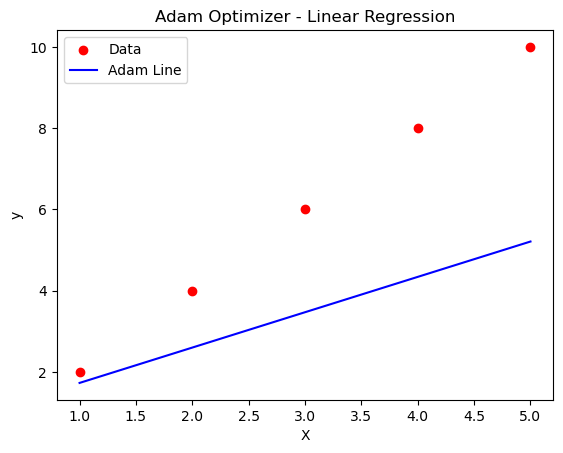

In [4]:
# Plotting
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Adam Line')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Adam Optimizer - Linear Regression")
plt.show()

# Regularized Optimization Objective
A Regularized Optimization Objective is used to prevent overfitting by adding a penalty term to the loss function. This encourages the model to keep its weights small or sparse, leading to simpler models that generalize better.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
X = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Initialize parameters
theta0 = 0
theta1 = 0
alpha = 0.01
lambda_ = 0.1  # Regularization strength
iterations = 100
m = len(X)

# Gradient Descent with L2 regularization
for i in range(iterations):
    prediction = theta0 + theta1 * X
    error = prediction - y

    # Gradients with L2 penalty (excluding bias term)
    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X) + (lambda_ / m) * theta1

    # Update parameters
    theta0 -= alpha * d_theta0
    theta1 -= alpha * d_theta1

    # Optional: print loss
    if i % 10 == 0:
        loss = np.mean((prediction - y) ** 2) + (lambda_ / (2 * m)) * (theta1 ** 2)
        print(f"Iteration {i}: Loss = {loss:.4f}")

# Final parameters
print(f"\nFinal theta0: {theta0}, theta1: {theta1}")

Iteration 0: Loss = 44.0005
Iteration 10: Loss = 3.6217
Iteration 20: Loss = 0.3685
Iteration 30: Loss = 0.1031
Iteration 40: Loss = 0.0797
Iteration 50: Loss = 0.0765
Iteration 60: Loss = 0.0752
Iteration 70: Loss = 0.0740
Iteration 80: Loss = 0.0729
Iteration 90: Loss = 0.0719

Final theta0: 0.4417426564209273, theta1: 1.874471561350702


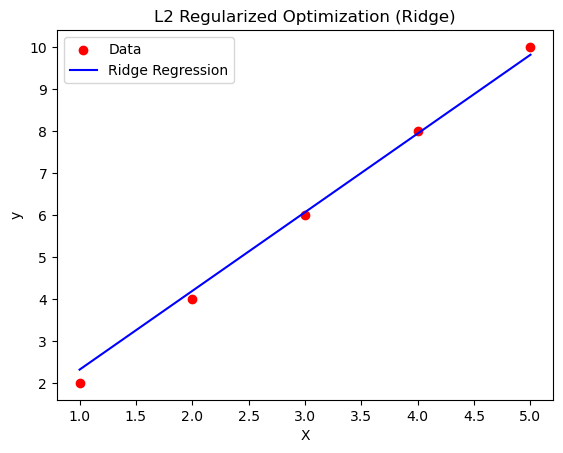

In [6]:
# Plot
plt.scatter(X, y, color='red', label='Data')
plt.plot(X, theta0 + theta1 * X, color='blue', label='Ridge Regression')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("L2 Regularized Optimization (Ridge)")
plt.show()